In [3]:
#is a binary classifier : separates two groups (+1 and -1), then two groups, etc. 
#trouver le meilleur hyperplan de séparation

import numpy as np
from sklearn import preprocessing, model_selection, svm
import pandas as pd

df=pd.read_csv('breast-cancer-wisconsin.data', encoding='ANSI')
df.replace('?', -99999, inplace=True) #replace the missing data with -99999
df.drop(['id'], 1, inplace=True) #drop the id column to avoid outliers

X=np.array(df.drop(['class'], 1))
#print(df.columns)
y=df['class']

X_train, X_test, y_train, y_test=model_selection.train_test_split(X,y, test_size=0.2)

clf=svm.SVC(kernel='linear')
clf.fit(X_train, y_train) #train it with the training data

accuracy=clf.score(X_test, y_test)

print (accuracy)

0.9642857142857143


# Making our own SVM

In [ ]:
import pandas as pd
import numpy as np
from sklearn import svm, datasets
import matplotlib.pyplot as plt

iris = datasets.load_iris() #input data
X = iris.data[:, :2]
y = iris.target

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
h = (x_max / x_min)/100
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
X_plot = np.c_[xx.ravel(), yy.ravel()]

#Now, we need to provide the value of regularization parameter as follows −

C = 1.0

Svc_classifier = svm.SVC(kernel='linear', C=C).fit(X, y)

Z = svc_classifier.predict(X_plot)
Z = Z.reshape(xx.shape)
plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.contourf(xx, yy, Z, cmap=plt.cm.tab10, alpha=0.3) #that is important 
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.xlim(xx.min(), xx.max())
plt.title('Support Vector Classifier with linear kernel')

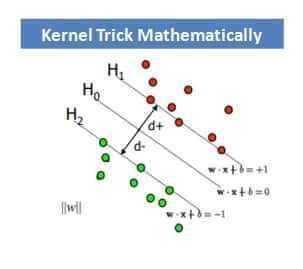

In [9]:
from IPython.display import Image
Image("SVM-Kernel-Trick-Mathematically.jpg") #afficher mon image

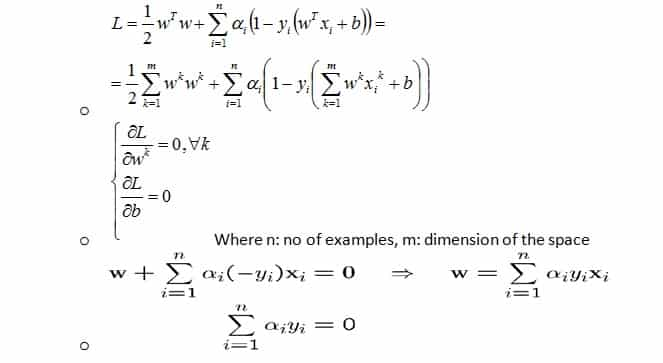

In [10]:
Image("SVM-formula-Example-1.jpg")

In [ ]:
Image("SVM-formula-Example-2.jpg")

In [ ]:
Image("SVM-formula-Example-3.jpg")

In [ ]:
Image("SVM-formula-Example-4.jpg")

In [ ]:
Image("SVM-formula-Example-11.jpg")

Optimized a step.
Optimized a step.
Optimized a step.


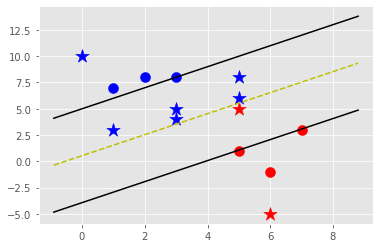

In [20]:
import matplotlib.pyplot as plt
from matplotlib import style
import numpy as np
style.use('ggplot')

class Support_Vector_Machine:
    def __init__(self, visualization=True): #définir les paramètres de visualisation
        self.visualization=visualization
        self.colors={1:'r', -1:'b'}
        if self.visualization:
            self.fig=plt.figure()
            self.ax=self.fig.add_subplot(1,1,1)
            
    def fit(self, data):
        self.data=data #le mot self va nous permettre d'optimiser
        opt_dict={}
        transforms=[[1,1],[-1,1],[-1,-1], [1,-1]] #multiplier le vecteur w arbitraire par ces vecteurs de transformation
        all_data=[]
        for yi in self.data: #yi parcourt data 
            for featureset in self.data[yi]:
                for feature in featureset:
                    all_data.append(feature)
        self.max_feature_value=max(all_data)#trouver le max et le min
        self.min_feature_value=min(all_data)
        all_data=None #vider la mémoire
        
        #support vectors = yi*(xi.w+b)=1 mais c'est qui xi?
        #the value of this should be close to 1
        step_sizes=[self.max_feature_value*0.1, #take big steps to find the minimum
                    self.max_feature_value*0.01, #take smaller steps to find the minimum
                    self.max_feature_value*0.001] #take very small steps to find the minimum
        
        b_range_multiple= 5 #extremely expensive
        
        b_multiple=5
        
        latest_optimum= self.max_feature_value*10 #partir du haut de la courbe puis descendre
        
        for step in step_sizes: #optimiser d'abord à la hache, puis de façon de plus en plus précise
            optimized=False
            w=np.array([latest_optimum,latest_optimum]) #pk w est un vecteur lambda*[1,1]???
            while not optimized:
                for b in np.arange(-1*(self.max_feature_value*b_range_multiple),self.max_feature_value*b_range_multiple, step*b_multiple):
                    #b varie de k*valeur_max à -k*valeur_max
                    for transformation in transforms:
                        w_t=w*transformation
                        found_option=True
                        for i in self.data:#parcourir les catégories du dictionnaire
                            # il faut que : yi*(xi.w+b)>=1
                            for xi in self.data[i]: #parcourir les vecteurs xi de chaque catégorie
                                yi=i #inverser le signe
                                #print(yi*(np.dot(w_t,xi)+b))
                                if not (yi*(np.dot(w_t,xi)+b)>=1):#évaluation par le lagrangien
                                    found_option=False #recommencer
                        if found_option:
                            opt_dict[np.linalg.norm(w_t)]=[w_t,b]#norme du vecteur
                                    
                if w[0]<0:
                    optimized=True
                    print ('Optimized a step.')
                else:
                    w=w-step
                    
            norms=sorted([n for n in opt_dict])
            opt_choice=opt_dict[norms[0]] #take the element of the dictionary with the smallest norm
            self.w=opt_choice[0]
            self.b=opt_choice[1]
            latest_optimum=opt_choice[0][0]+step*2
            
        for i in self.data:
                for xi in self.data[i]:
                    yi=i
                    print(xi,':',yi*(np.dot(self.w,xi)+self.b))    
            
    def predict(self, features):
        classification=np.sign(np.dot(np.array(features),self.w)+self.b)
        if classification!=0 and self.visualization:
            self.ax.scatter(features[0], features[1], s=200, marker='*', c=self.colors[classification])
        return classification
    
    def visualize(self):
        [[self.ax.scatter(x[0],x[1], s=100, color=self.colors[i]) for x in data_dict[i]] for i in data_dict]
        
        def hyperplane(x,w,b,v):
        #v=x.w+b
            return (-w[0]*x-b+v)/w[1] #why????
        datarange=(self.min_feature_value*0.9, self.max_feature_value*1.1)
        hyp_x_max=datarange[1]
        hyp_x_min=datarange[0]
        #positive support vector
        psv1=hyperplane(hyp_x_min, self.w, self.b, 1)
        psv2=hyperplane(hyp_x_max, self.w, self.b, 1)
        self.ax.plot([hyp_x_min,hyp_x_max],[psv1,psv2],'k')
        #negative support vector
        nsv1=hyperplane(hyp_x_min, self.w, self.b, -1)
        nsv2=hyperplane(hyp_x_max, self.w, self.b, -1)
        self.ax.plot([hyp_x_min,hyp_x_max],[nsv1,nsv2], 'k')
        #decision boundary
        dsv1=hyperplane(hyp_x_min, self.w, self.b, 0)
        dsv2=hyperplane(hyp_x_max, self.w, self.b, 0)
        self.ax.plot([hyp_x_min,hyp_x_max],[dsv1,dsv2],'y--')
        plt.show()
        
data_dict={-1: np.array([[1,7], [2,8], [3,8]]), 1: np.array([[5,1], [6,-1], [7,3]])}

svm=Support_Vector_Machine()
svm.fit(data=data_dict)
predict_us = [[0,10],
              [1,3],
              [3,4],
              [3,5],
              [5,5],
              [5,6],
              [6,-5],
              [5,8]]

for p in predict_us:
    svm.predict(p)

svm.visualize()

Optimized a step.
Optimized a step.
Optimized a step.


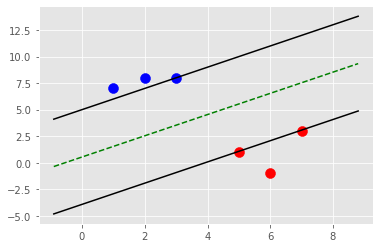

In [16]:
import matplotlib.pyplot as plt
from matplotlib import style
import numpy as np
style.use('ggplot')

class Support_Vector_Machine:
    def __init__(self, visualization=True):
        self.visualization = visualization
        self.colors = {1:'r',-1:'b'}
        if self.visualization:
            self.fig = plt.figure()
            self.ax = self.fig.add_subplot(1,1,1)
    # train
    def fit(self, data):
        self.data = data
        # { ||w||: [w,b] }
        opt_dict = {}

        transforms = [[1,1],
                      [-1,1],
                      [-1,-1],
                      [1,-1]]

        all_data = []
        for yi in self.data:
            for featureset in self.data[yi]:
                for feature in featureset:
                    all_data.append(feature)

        self.max_feature_value = max(all_data)
        self.min_feature_value = min(all_data)
        all_data = None

        # support vectors yi(xi.w+b) = 1
        

        step_sizes = [self.max_feature_value * 0.1,
                      self.max_feature_value * 0.01,
                      # point of expense:
                      self.max_feature_value * 0.001,]

        
        
        # extremely expensive
        b_range_multiple = 5
        # we dont need to take as small of steps
        # with b as we do w
        b_multiple = 5
        latest_optimum = self.max_feature_value*10

        for step in step_sizes:
            w = np.array([latest_optimum,latest_optimum])
            # we can do this because convex
            optimized = False
            while not optimized:
                for b in np.arange(-1*(self.max_feature_value*b_range_multiple),
                                   self.max_feature_value*b_range_multiple,
                                   step*b_multiple):
                    for transformation in transforms:
                        w_t = w*transformation
                        found_option = True
                        # weakest link in the SVM fundamentally
                        # SMO attempts to fix this a bit
                        # yi(xi.w+b) >= 1
                        # 
                        # #### add a break here later..
                        for i in self.data:
                            for xi in self.data[i]:
                                yi=i
                                if not yi*(np.dot(w_t,xi)+b) >= 1:
                                    found_option = False
                                    
                        if found_option:
                            opt_dict[np.linalg.norm(w_t)] = [w_t,b]

                if w[0] < 0:
                    optimized = True
                    print('Optimized a step.')
                else:
                    w = w - step

            norms = sorted([n for n in opt_dict])
            #||w|| : [w,b]
            opt_choice = opt_dict[norms[0]]
            self.w = opt_choice[0]
            self.b = opt_choice[1]
            latest_optimum = opt_choice[0][0]+step*2
            

    def predict(self,features):
        # classifiction is just:
        # sign(xi.w+b)
        classification = np.sign(np.dot(np.array(features),self.w)+self.b)
        # if the classification isn't zero, and we have visualization on, we graph
        if classification != 0 and self.visualization:
            self.ax.scatter(features[0],features[1],s=200,marker='*', c=self.colors[classification])
        else:
            print('featureset',features,'is on the decision boundary')
        return classification
    
    def visualize(self):
        #scattering known featuresets.
        [[self.ax.scatter(x[0],x[1],s=100,color=self.colors[i]) for x in data_dict[i]] for i in data_dict]
        def hyperplane(x,w,b,v):
            # v = (w.x+b)
            return (-w[0]*x-b+v) / w[1]
        
        datarange = (self.min_feature_value*0.9,self.max_feature_value*1.1)
        hyp_x_min = datarange[0]
        hyp_x_max = datarange[1]
        
        # w.x + b = 1
        # pos sv hyperplane
        psv1 = hyperplane(hyp_x_min, self.w, self.b, 1)
        psv2 = hyperplane(hyp_x_max, self.w, self.b, 1)
        self.ax.plot([hyp_x_min,hyp_x_max], [psv1,psv2], "k")

        # w.x + b = -1
        # negative sv hyperplane
        nsv1 = hyperplane(hyp_x_min, self.w, self.b, -1)
        nsv2 = hyperplane(hyp_x_max, self.w, self.b, -1)
        self.ax.plot([hyp_x_min,hyp_x_max], [nsv1,nsv2], "k")

        # w.x + b = 0
        # decision
        db1 = hyperplane(hyp_x_min, self.w, self.b, 0)
        db2 = hyperplane(hyp_x_max, self.w, self.b, 0)
        self.ax.plot([hyp_x_min,hyp_x_max], [db1,db2], "g--")

        plt.show()
        
data_dict = {-1:np.array([[1,7],
                          [2,8],
                          [3,8],]),
             
             1:np.array([[5,1],
                         [6,-1],
                         [7,3],])}

svm=Support_Vector_Machine()
svm.fit(data=data_dict)
svm.visualize()